<a href="https://colab.research.google.com/github/AssetBayan/Data-Standardisation-2026.12.03/blob/main/Seaborn_Tips_Data_Distribution_and_Sampling_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tips = sns.load_dataset("tips")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


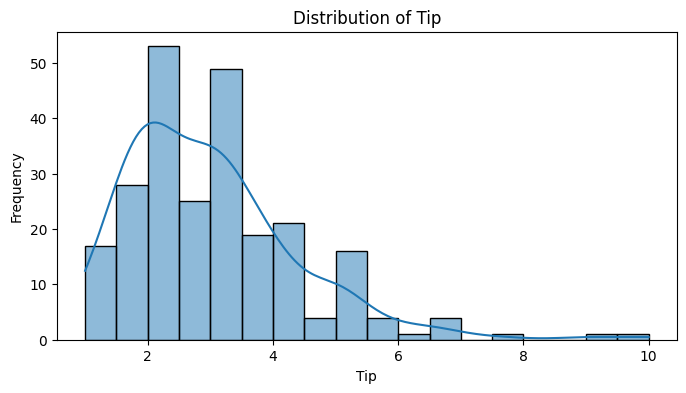

In [3]:
plt.figure(figsize=(8,4))

sns.histplot(tips['tip'], kde=True)

plt.title("Distribution of Tip")
plt.xlabel("Tip")
plt.ylabel("Frequency")

plt.show()

In [4]:
mean_tip = tips['tip'].mean()
variance_tip = tips['tip'].var()

print("Mean of tip:", mean_tip)
print("Variance of tip:", variance_tip)

Mean of tip: 2.99827868852459
Variance of tip: 1.9144546380624725


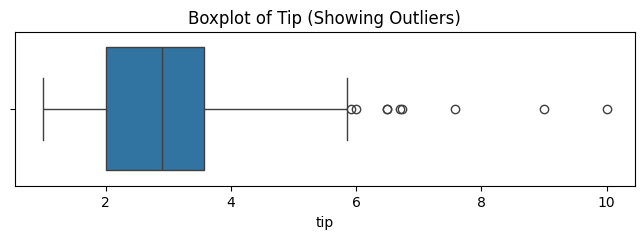

In [5]:
plt.figure(figsize=(8,2))

sns.boxplot(x=tips['tip'])

plt.title("Boxplot of Tip (Showing Outliers)")

plt.show()

In [6]:
median_tip = tips['tip'].median()

print("Mean:", mean_tip)
print("Median:", median_tip)

Mean: 2.99827868852459
Median: 2.9


In [7]:
pop_mean = tips['tip'].mean()
pop_var = tips['tip'].var()

print("Population Mean:", pop_mean)
print("Population Variance:", pop_var)

Population Mean: 2.99827868852459
Population Variance: 1.9144546380624725


In [8]:
sample_random = tips.sample(n=30, random_state=1)

mean_random = sample_random['tip'].mean()
var_random = sample_random['tip'].var()

print("Random Sample Mean:", mean_random)
print("Random Sample Variance:", var_random)

Random Sample Mean: 3.228666666666667
Random Sample Variance: 3.4318947126436794


In [9]:
sample_systematic = tips.iloc[::8]

mean_sys = sample_systematic['tip'].mean()
var_sys = sample_systematic['tip'].var()

print("Systematic Sample Mean:", mean_sys)
print("Systematic Sample Variance:", var_sys)

Systematic Sample Mean: 2.736774193548387
Systematic Sample Variance: 0.9710692473118279


In [10]:
sample_stratified = tips.groupby("sex").sample(n=15, random_state=1)

mean_str = sample_stratified['tip'].mean()
var_str = sample_stratified['tip'].var()

print("Stratified Sample Mean:", mean_str)
print("Stratified Sample Variance:", var_str)

Stratified Sample Mean: 3.2810000000000006
Stratified Sample Variance: 1.9059748275862065


/tmp/ipykernel_621/3137505085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_stratified = tips.groupby("sex").sample(n=15, random_state=1)


In [11]:
comparison = pd.DataFrame({
    "Method": ["Population", "Random", "Systematic", "Stratified"],
    "Mean": [pop_mean, mean_random, mean_sys, mean_str],
    "Variance": [pop_var, var_random, var_sys, var_str]
})

comparison

,Method,Mean,Variance
0,Population,2.998279,1.914455
1,Random,3.228667,3.431895
2,Systematic,2.736774,0.971069
3,Stratified,3.281000,1.905975


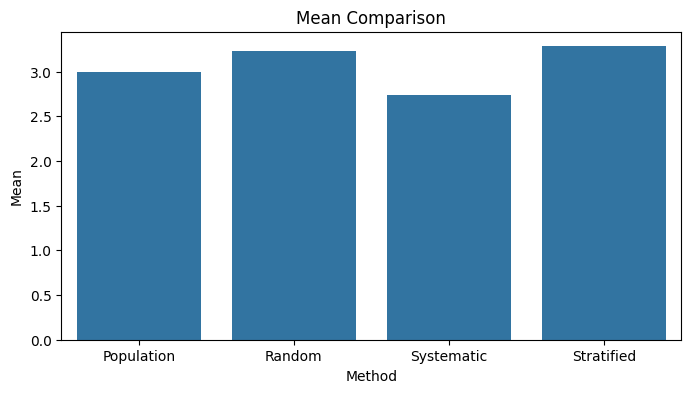

In [12]:
plt.figure(figsize=(8,4))

sns.barplot(x="Method", y="Mean", data=comparison)

plt.title("Mean Comparison")

plt.show()

Among the three sampling methods, simple random sampling and stratified sampling produce means and variances closer to the population values. Stratified sampling can be more reliable because it preserves the structure of the population groups.